# Bottleneck N-T Diagram With Zone Speed Factor

This notebook runs the shared community bottleneck example twice and compares the resulting $N$-$T$ diagrams at a measurement line behind the slowdown zone.

- Run 1 uses zone `speed_factor = 1.0`
- Run 2 uses zone `speed_factor = 0.5`

The final plot shows both runs side by side using `pedpy.plot_nt(..., axes=...)`.

In [ ]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import pedpy

from core.scenario import Scenario, load_scenario, run_scenario

In [ ]:
SCENARIO_DIR = Path("scenarios") / "bottleneck-zone"
MEASUREMENT_LINE = pedpy.MeasurementLine([(11.5, 0.0), (11.5, 2.0)])

scenario = load_scenario(str(SCENARIO_DIR))
scenario.summary()

## Helper Functions

We deep-copy the loaded scenario data before changing the zone speed factor. This keeps the baseline and modified runs independent, because nested edits to `scenario.raw` would otherwise leak into later runs.

In [ ]:
def clone_scenario(base: Scenario, raw: dict) -> Scenario:
    sim_params = raw.get("config", {})\
        .get("simulation_settings", {})\
        .get("simulationParams", base.sim_params)
    return Scenario(
        raw=raw,
        walkable_area_wkt=base.walkable_area_wkt,
        model_type=sim_params.get("model_type", base.model_type),
        seed=raw.get("config", {})
        .get("simulation_settings", {})
        .get("baseSeed", base.seed),
        sim_params=sim_params,
        source_path=base.source_path,
    )


def run_nt_variant(base: Scenario, speed_factor: float):
    raw = deepcopy(base.raw)
    raw["zones"]["jps-zones_0"]["speed_factor"] = float(speed_factor)
    variant = clone_scenario(base, raw)
    result = run_scenario(variant, seed=42)
    traj = pedpy.TrajectoryData(
        result.trajectory_dataframe()[["id", "frame", "x", "y"]],
        frame_rate=result.frame_rate,
    )
    nt, crossing_frames = pedpy.compute_n_t(
        traj_data=traj,
        measurement_line=MEASUREMENT_LINE,
    )
    return {
        "speed_factor": speed_factor,
        "result": result,
        "trajectory": traj,
        "nt": nt,
        "crossing_frames": crossing_frames,
    }

## Baseline Run

First run the bottleneck with zone `speed_factor = 1.0`.

In [ ]:
baseline = run_nt_variant(scenario, speed_factor=1.0)
baseline["result"].metrics

## Slowdown Run

Now change the zone speed factor to `0.5` and rerun.

In [ ]:
slow_zone = run_nt_variant(scenario, speed_factor=0.5)
slow_zone["result"].metrics

## Side-By-Side N-T Diagrams

The slower zone should delay cumulative crossings at the measurement line.

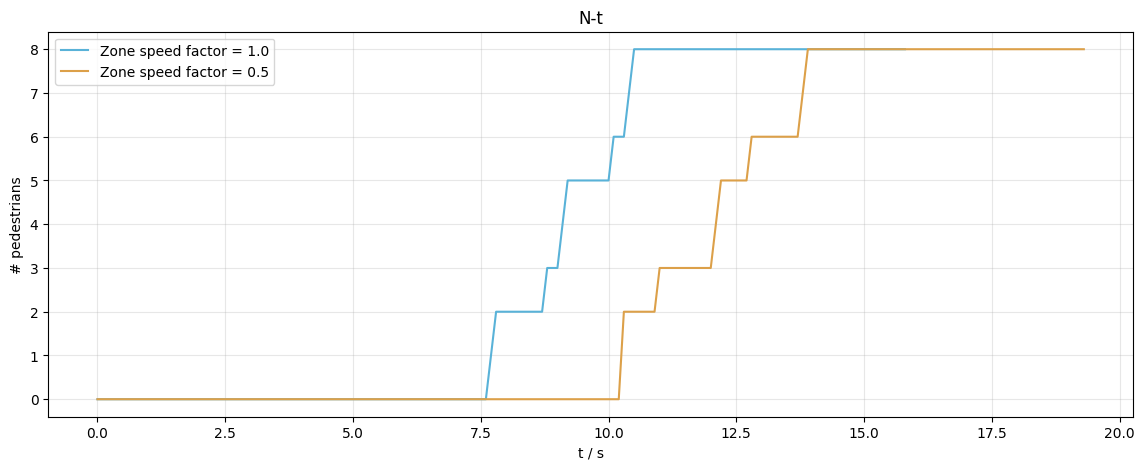

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

pedpy.plot_nt(
    nt=baseline["nt"],
    axes=axes,
    label="Zone speed factor = 1.0",
    color=pedpy.PEDPY_BLUE,
)

pedpy.plot_nt(
    nt=slow_zone["nt"],
    axes=axes,
    label="Zone speed factor = 0.5",
    color=pedpy.PEDPY_ORANGE,    
)
axes.legend()
axes.grid(alpha=0.3)

## Cleanup

Delete the temporary SQLite files when you are done.

In [ ]:
baseline["result"].cleanup()
slow_zone["result"].cleanup()